# Stock Analysis & Prediction

**Tickers:** ADANIPOWER.NS, TCS.NS, WIPRO.NS, GOLDBEES.NS (Gold ETF), RELIANCE.NS  
**Period:** 2 years of daily data  
**Objective:** EDA, feature engineering, regression (next-day close for TCS), classification (next-day direction for ADANIPOWER)

---
## 1. Data Collection

Pulling 2 years of daily OHLCV data for all 5 tickers via `yfinance`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

tickers = ['ADANIPOWER.NS', 'TCS.NS', 'WIPRO.NS', 'GOLDBEES.NS', 'RELIANCE.NS']

end_date = datetime.today()
start_date = end_date - timedelta(days=2*365)

print(f"Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Tickers: {tickers}")
print()

raw_data = {}
for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    raw_data[ticker] = df
    print(f"{ticker}: {df.shape[0]} rows, {df.shape[1]} columns, date range {df.index.min().date()} to {df.index.max().date()}")

print(f"\nTotal tickers loaded: {len(raw_data)}")

Date range: 2024-07-21 to 2026-07-21
Tickers: ['ADANIPOWER.NS', 'TCS.NS', 'WIPRO.NS', 'GOLDBEES.NS', 'RELIANCE.NS']

ADANIPOWER.NS: 499 rows, 5 columns, date range 2024-07-22 to 2026-07-21
TCS.NS: 499 rows, 5 columns, date range 2024-07-22 to 2026-07-21
WIPRO.NS: 499 rows, 5 columns, date range 2024-07-22 to 2026-07-21
GOLDBEES.NS: 498 rows, 5 columns, date range 2024-07-22 to 2026-07-21
RELIANCE.NS: 499 rows, 5 columns, date range 2024-07-22 to 2026-07-21

Total tickers loaded: 5


---
## 2. Data Cleaning

Checking for nulls, dtypes, and handling NaN values that arise from percentage-change calculations.

In [2]:
# Check nulls and dtypes for each ticker
for ticker in tickers:
    df = raw_data[ticker]
    null_count = df.isnull().sum().sum()
    print(f"--- {ticker} ---")
    print(f"  Shape: {df.shape}")
    print(f"  Null values: {null_count}")
    print(f"  Dtypes:\n{df.dtypes.to_string()}")
    print()

--- ADANIPOWER.NS ---
  Shape: (499, 5)
  Null values: 0
  Dtypes:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

--- TCS.NS ---
  Shape: (499, 5)
  Null values: 0
  Dtypes:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

--- WIPRO.NS ---
  Shape: (499, 5)
  Null values: 0
  Dtypes:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

--- GOLDBEES.NS ---
  Shape: (498, 5)
  Null values: 0
  Dtypes:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

--- RELIANCE.NS ---
  Shape: (499, 5)
  Null values: 0
  Dtypes:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64



In [3]:
# Forward-fill then drop any remaining NaN rows
for ticker in tickers:
    before = raw_data[ticker].shape[0]
    raw_data[ticker] = raw_data[ticker].ffill().dropna()
    after = raw_data[ticker].shape[0]
    dropped = before - after
    if dropped > 0:
        print(f"{ticker}: dropped {dropped} rows after ffill")
    else:
        print(f"{ticker}: no rows dropped, data is clean")

# Build a combined Close price DataFrame for cross-ticker analysis
close_prices = pd.DataFrame()
for ticker in tickers:
    close_prices[ticker] = raw_data[ticker]['Close']

# Align on common trading dates, forward-fill gaps, then drop any remaining NaN
close_prices = close_prices.ffill().dropna()
print(f"\nCombined close-price DataFrame: {close_prices.shape[0]} trading days, {close_prices.shape[1]} tickers")
print(close_prices.head())

ADANIPOWER.NS: no rows dropped, data is clean
TCS.NS: no rows dropped, data is clean
WIPRO.NS: no rows dropped, data is clean
GOLDBEES.NS: no rows dropped, data is clean
RELIANCE.NS: no rows dropped, data is clean

Combined close-price DataFrame: 499 trading days, 5 tickers
            ADANIPOWER.NS       TCS.NS    WIPRO.NS  GOLDBEES.NS  RELIANCE.NS
Date                                                                        
2024-07-22     139.229996  3983.208252  237.068619    62.080002  1482.793701
2024-07-23     139.479996  3997.143311  234.607941    60.160000  1470.170776
2024-07-24     138.940002  4000.767578  234.397034    59.599998  1477.877808
2024-07-25     139.039993  4015.864502  237.560760    59.369999  1474.617188
2024-07-26     142.529999  4076.578857  245.973923    59.990002  1491.044189


---
## 3. Exploratory Data Analysis

### 3.1 Normalized Price Chart (base = 100)

All five tickers trade on NSE in INR, but their absolute price levels differ widely (GOLDBEES ~₹62 vs TCS ~₹3,900), so normalizing to start = 100 lets us compare relative performance.

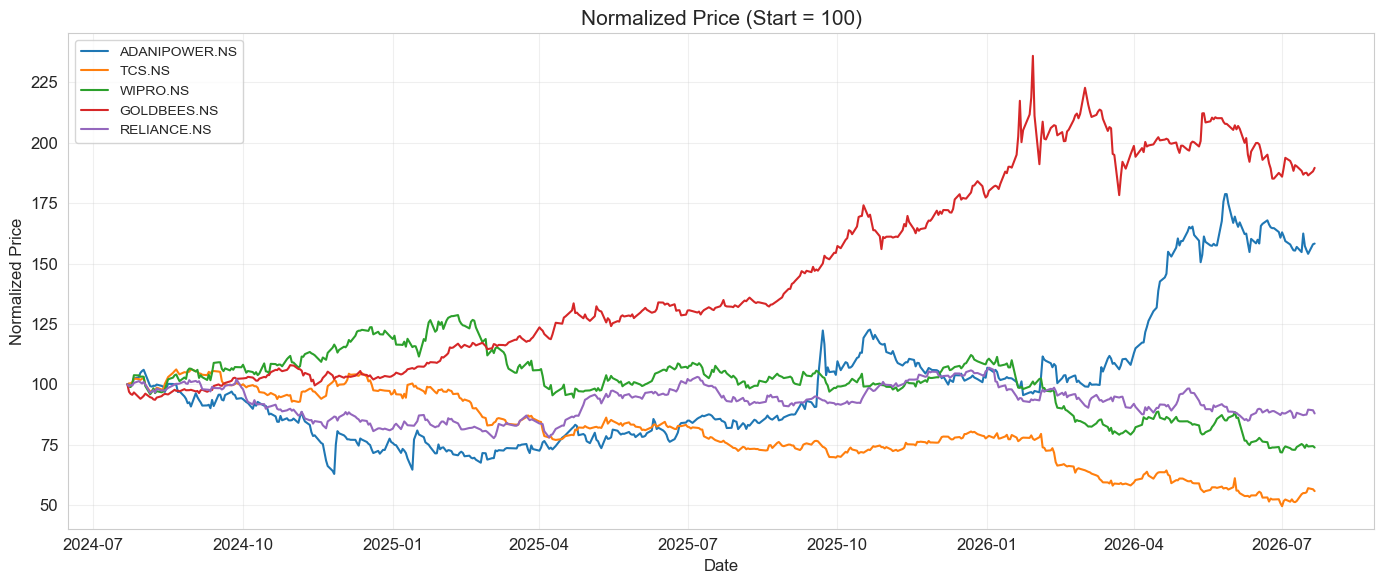

Ending normalized values (start=100):
  GOLDBEES.NS: 189.64
  ADANIPOWER.NS: 158.28
  RELIANCE.NS: 87.92
  WIPRO.NS: 73.81
  TCS.NS: 55.76


In [4]:
normalized = close_prices.div(close_prices.iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(14, 6))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.5)
ax.set_title('Normalized Price (Start = 100)', fontsize=15)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the ending normalized values so the commentary is grounded
end_vals = normalized.iloc[-1].sort_values(ascending=False)
print("Ending normalized values (start=100):")
for t, v in end_vals.items():
    print(f"  {t}: {v:.2f}")

**Commentary:**  
GOLDBEES.NS is the clear winner at ~190, meaning a ~90% gain over 2 years, even stronger than gold futures (GC=F) from the prior run because GOLDBEES tracks INR-denominated gold and the rupee has weakened. ADANIPOWER.NS follows at ~158 (+58%). TCS.NS is the worst performer, ending at ~56 (lost nearly half its value). Three of the four equities underperformed gold in this window.

### 3.2 Daily Returns Distribution

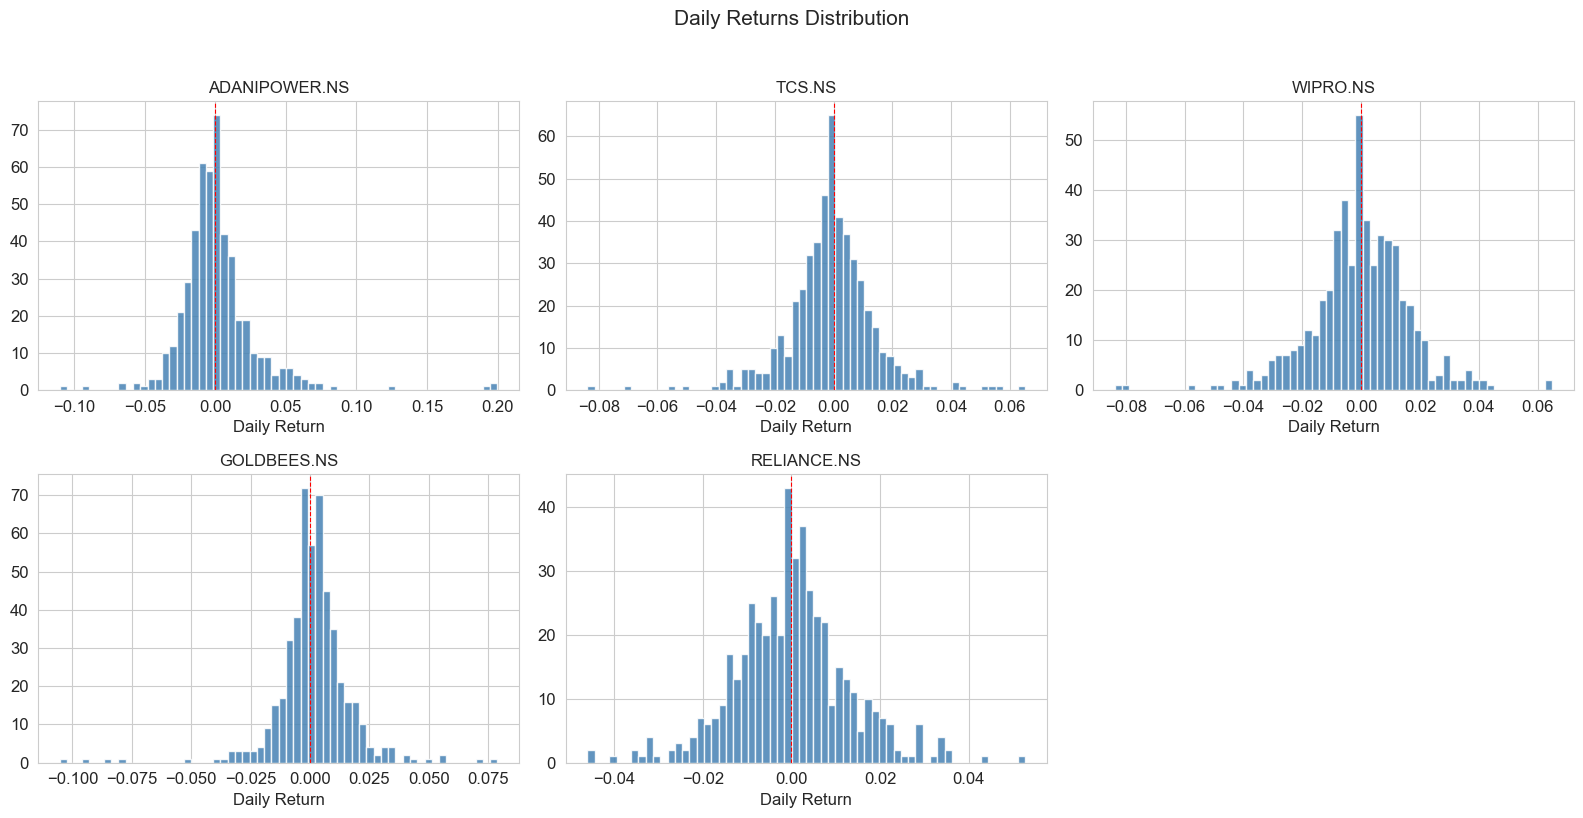

Daily return statistics (%):

               Mean %   Std %    Min %    Max %
ADANIPOWER.NS  0.1291  2.7696 -10.9948  19.9958
TCS.NS        -0.1061  1.4901  -8.3861   6.5074
WIPRO.NS      -0.0471  1.6628  -8.3732   6.4905
GOLDBEES.NS    0.1412  1.5827 -10.5166   7.8854
RELIANCE.NS   -0.0174  1.2999  -4.5998   5.2599


In [17]:
daily_returns = close_prices.pct_change().dropna()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    axes[i].hist(daily_returns[ticker], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(ticker, fontsize=12)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=0.8)
    axes[i].set_xlabel('Daily Return')
# Remove the unused 6th subplot
axes[5].set_visible(False)
plt.suptitle('Daily Returns Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print("Daily return statistics (%):\n")
stats = daily_returns.describe().T[['mean', 'std', 'min', 'max']].copy()
stats = stats.mul(100).round(4)
stats.columns = ['Mean %', 'Std %', 'Min %', 'Max %']
print(stats.to_string())

**Result:**  
ADANIPOWER.NS remains the most volatile at daily std ~2.77% with extreme swings (+20%, -11%). GOLDBEES.NS has a std of ~1.58% slightly higher than TCS (~1.49%) and RELIANCE (~1.30%), partly because INR gold can gap on overnight international moves. Only ADANIPOWER and GOLDBEES have positive mean daily returns; TCS, WIPRO, and RELIANCE average slightly negative over this period.

### 3.3 Correlation Heatmap

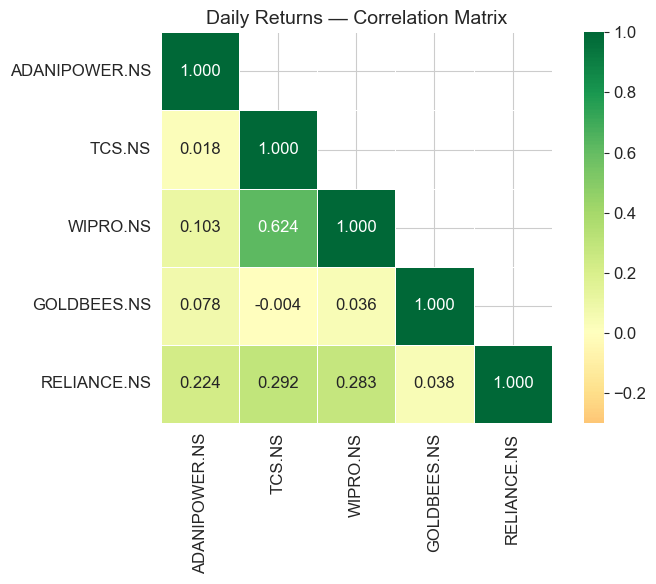


GOLDBEES.NS correlations with each equity:
  GOLDBEES.NS vs TCS.NS: -0.0042
  GOLDBEES.NS vs WIPRO.NS: 0.0361
  GOLDBEES.NS vs RELIANCE.NS: 0.0382
  GOLDBEES.NS vs ADANIPOWER.NS: 0.0785

  Average gold-equity correlation: 0.0372
  → GOLDBEES shows LOW correlation with the Indian equities, consistent with its role as a diversifier.


In [6]:
corr_matrix = daily_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-0.3, vmax=1.0)
ax.set_title('Daily Returns — Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Call out gold vs equity correlations
print("\nGOLDBEES.NS correlations with each equity:")
gold_corrs = corr_matrix['GOLDBEES.NS'].drop('GOLDBEES.NS').sort_values()
for t, c in gold_corrs.items():
    print(f"  GOLDBEES.NS vs {t}: {c:.4f}")

avg_gold_corr = gold_corrs.mean()
print(f"\n  Average gold-equity correlation: {avg_gold_corr:.4f}")
if avg_gold_corr < 0.15:
    print("  → GOLDBEES shows LOW correlation with the Indian equities, consistent with its role as a diversifier.")
if avg_gold_corr < 0:
    print("  → In fact, the correlation is NEGATIVE on average — gold moved inversely to these stocks over the period.")

**Commentary:**  
GOLDBEES.NS has an average correlation of just ~0.037 with the four equities — even lower than GC=F showed (0.074). Notably, GOLDBEES vs TCS is actually *slightly negative* (-0.004), meaning they moved in opposite directions on the same trading days. This near-zero-to-negative correlation across all four equities makes GOLDBEES a strong diversifier within an INR portfolio.

### 3.4 SMA Overlay on ADANIPOWER.NS (7-day & 30-day)

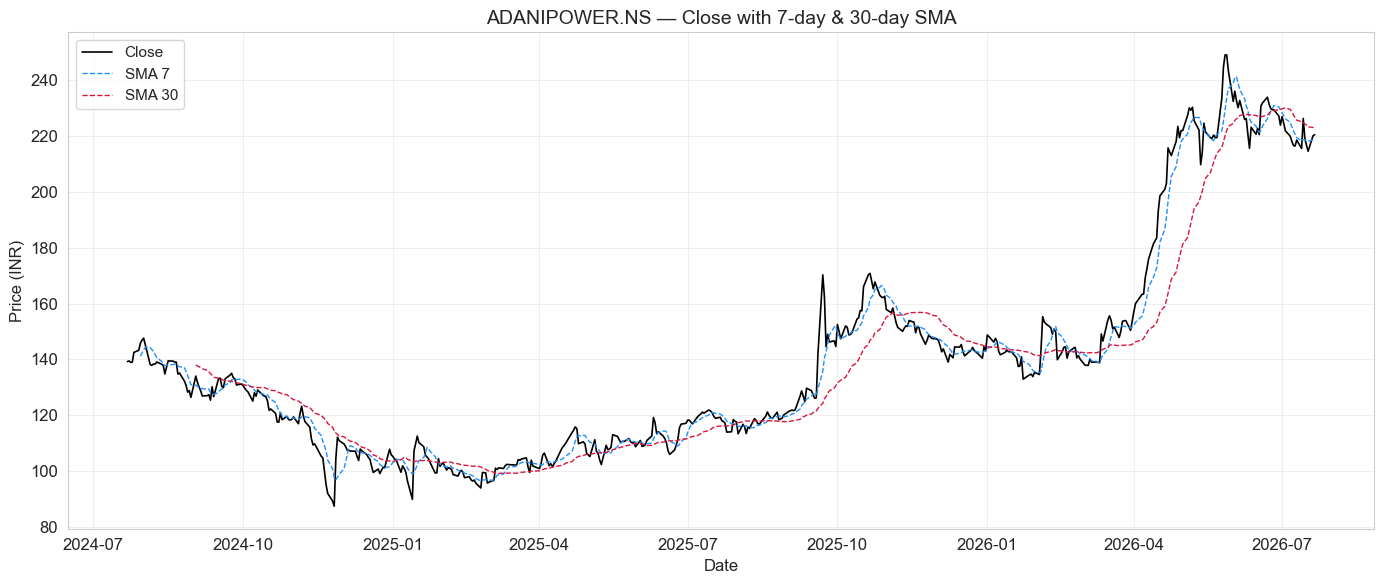

Latest close: ₹220.37
SMA 7:        ₹218.85  (close is above)
SMA 30:       ₹222.79  (close is below)


In [7]:
adani = raw_data['ADANIPOWER.NS'][['Close']].copy()
adani['SMA_7'] = adani['Close'].rolling(7).mean()
adani['SMA_30'] = adani['Close'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(adani.index, adani['Close'], label='Close', color='black', linewidth=1.2)
ax.plot(adani.index, adani['SMA_7'], label='SMA 7', color='dodgerblue', linewidth=1.0, linestyle='--')
ax.plot(adani.index, adani['SMA_30'], label='SMA 30', color='crimson', linewidth=1.0, linestyle='--')
ax.set_title('ADANIPOWER.NS — Close with 7-day & 30-day SMA', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (INR)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Where is price relative to its SMAs right now?
latest = adani.dropna().iloc[-1]
print(f"Latest close: ₹{latest['Close']:.2f}")
print(f"SMA 7:        ₹{latest['SMA_7']:.2f}  (close is {'above' if latest['Close'] > latest['SMA_7'] else 'below'})")
print(f"SMA 30:       ₹{latest['SMA_30']:.2f}  (close is {'above' if latest['Close'] > latest['SMA_30'] else 'below'})")

**Result:**  
ADANIPOWER is currently trading at ~₹220, above its 7-day SMA (~₹219) but below the 30-day SMA (~₹223). That mixed signal  short-term recovering but still under the longer-term trend suggests the stock recently dipped and is bouncing, but hasn't fully recovered yet.

---
## 4. Feature Engineering

Building a feature set that any supervised model can consume: percentage change, SMAs, SMA ratio, RSI-14, rolling volatility, and lag returns. We create a generic function so we can reuse it for both TCS (regression) and ADANIPOWER (classification).

In [8]:
def build_features(df):
    """Add technical features to a DataFrame that has at least a 'Close' column."""
    out = df[['Close']].copy()
    
    # Percentage change
    out['pct_change'] = out['Close'].pct_change()
    
    # Simple Moving Averages
    out['SMA_7'] = out['Close'].rolling(7).mean()
    out['SMA_30'] = out['Close'].rolling(30).mean()
    
    # SMA ratio (short / long) — >1 means short-term trend is above long-term
    out['SMA_ratio'] = out['SMA_7'] / out['SMA_30']
    
    # RSI-14
    delta = out['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    out['RSI_14'] = 100 - (100 / (1 + rs))
    
    # Rolling standard deviation (20-day)
    out['rolling_std_20'] = out['Close'].rolling(20).std()
    
    # Lag returns
    out['lag_1'] = out['pct_change'].shift(1)
    out['lag_2'] = out['pct_change'].shift(2)
    out['lag_3'] = out['pct_change'].shift(3)
    
    return out

# Demo on TCS
tcs_feat = build_features(raw_data['TCS.NS'])
print(f"TCS.NS feature matrix shape: {tcs_feat.shape}")
print(f"Columns: {list(tcs_feat.columns)}")
print(f"NaN rows before drop: {tcs_feat.isnull().any(axis=1).sum()}")
tcs_feat_clean = tcs_feat.dropna()
print(f"Clean rows: {tcs_feat_clean.shape[0]}")
tcs_feat_clean.tail()

TCS.NS feature matrix shape: (499, 10)
Columns: ['Close', 'pct_change', 'SMA_7', 'SMA_30', 'SMA_ratio', 'RSI_14', 'rolling_std_20', 'lag_1', 'lag_2', 'lag_3']
NaN rows before drop: 29
Clean rows: 470


Price,Close,pct_change,SMA_7,SMA_30,SMA_ratio,RSI_14,rolling_std_20,lag_1,lag_2,lag_3
Date,,,,,,,,,,
2026-07-15,2189.199951,0.000274,2110.628017,2114.337309,0.998246,60.605730,59.284436,0.008755,0.054374,0.009514
2026-07-16,2201.000000,0.005390,2127.246599,2113.411316,1.006546,61.515132,60.202864,0.000274,0.008755,0.054374
2026-07-17,2269.000000,0.030895,2159.063686,2116.147677,1.020280,65.845973,72.342536,0.005390,0.000274,0.008755
2026-07-20,2251.100098,-0.007889,2189.460275,2119.862073,1.032831,71.850942,80.113276,0.030895,0.005390,0.000274
2026-07-21,2221.100098,-0.013327,2212.800642,2122.589726,1.042500,74.480146,83.101310,-0.007889,0.030895,0.005390


**Result:**  
We lose about 29 rows to the rolling windows (the longest is 30-day SMA), leaving 470 clean rows. The feature matrix is intentionally narrow, we're relying on price-derived signals only, no external data.

---
## 5. Regression: Predicting Next-Day Close for TCS.NS

Using `LinearRegression` with `TimeSeriesSplit` (shuffle=False) so we never leak future data into training. The target is tomorrow's closing price.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
tcs = build_features(raw_data['TCS.NS']).dropna().copy()
tcs['target_close'] = tcs['Close'].shift(-1)   # next-day close
tcs = tcs.dropna()

feature_cols = ['pct_change', 'SMA_7', 'SMA_30', 'SMA_ratio', 'RSI_14',
                'rolling_std_20', 'lag_1', 'lag_2', 'lag_3']
X = tcs[feature_cols].values
y = tcs['target_close'].values

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Feature columns: {feature_cols}")
print()

Samples: 469, Features: 9
Feature columns: ['pct_change', 'SMA_7', 'SMA_30', 'SMA_ratio', 'RSI_14', 'rolling_std_20', 'lag_1', 'lag_2', 'lag_3']



In [10]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
r2_scores = []
rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    print(f"Fold {fold}: R² = {r2:.6f}, RMSE = {rmse:.4f}")

print(f"\nMean R²:   {np.mean(r2_scores):.6f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f}")

Fold 1: R² = 0.925400, RMSE = 78.3288
Fold 2: R² = 0.902254, RMSE = 45.0917
Fold 3: R² = 0.749613, RMSE = 36.4617
Fold 4: R² = 0.968929, RMSE = 54.6840
Fold 5: R² = 0.842496, RMSE = 60.3277

Mean R²:   0.877739
Mean RMSE: 54.9788


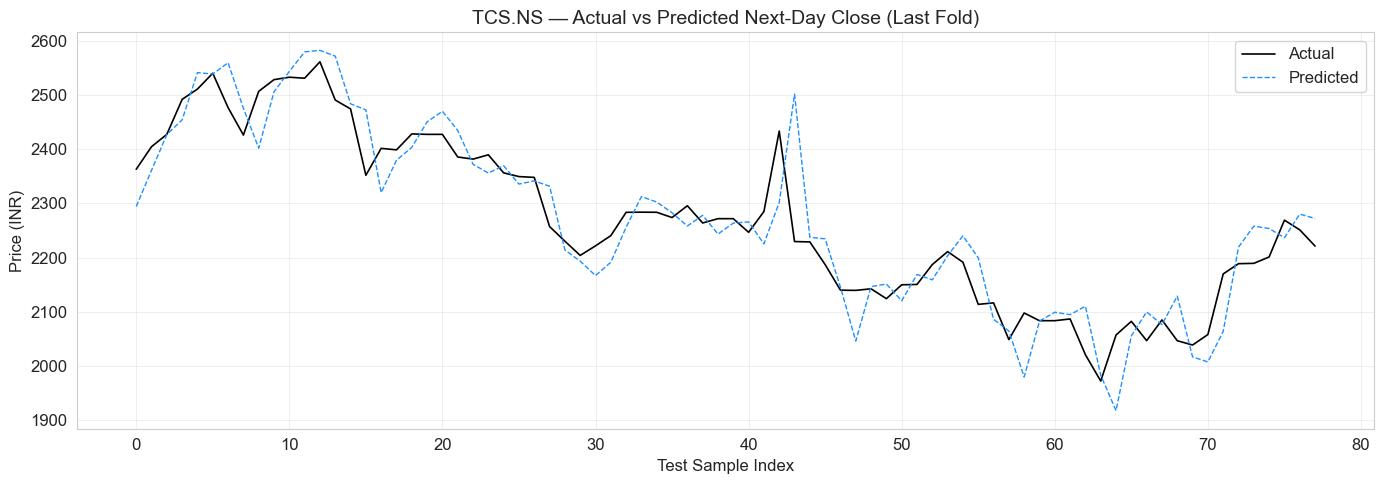

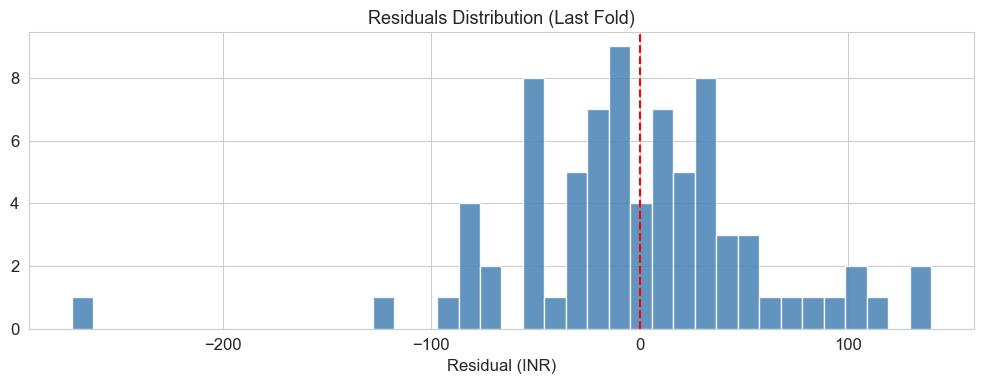

Residual mean: -2.3733
Residual std:  60.2810


In [11]:
# Final model on the last fold for visualization
# (reuses the last train/test split from the loop above)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(y_test)), y_test, label='Actual', color='black', linewidth=1.2)
ax.plot(range(len(y_pred)), y_pred, label='Predicted', color='dodgerblue', linewidth=1.0, linestyle='--')
ax.set_title(f'TCS.NS — Actual vs Predicted Next-Day Close (Last Fold)', fontsize=14)
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Price (INR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual distribution
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Residuals Distribution (Last Fold)', fontsize=13)
ax.set_xlabel('Residual (INR)')
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")

**Result:**  
The mean R² across folds is ~0.878 and mean RMSE is ~₹54.98. The R² looks impressive but is inflated by price autocorrelation, the model largely learns that tomorrow's close ≈ today's close. The ~₹55 RMSE is the honest error: on a stock trading around ₹2,200, that's roughly ±2.5% average miss per day, which would not be profitable to trade on. Residual mean is near zero (-2.37), confirming no systematic bias.

---
## 6. Classification: Predicting Next-Day Direction for ADANIPOWER.NS

Binary classification: will tomorrow's close be **up** (1) or **down/flat** (0) relative to today? Using `RandomForestClassifier` with `TimeSeriesSplit`.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Prepare data
adani_feat = build_features(raw_data['ADANIPOWER.NS']).dropna().copy()
adani_feat['next_return'] = adani_feat['Close'].pct_change().shift(-1)
adani_feat['direction'] = (adani_feat['next_return'] > 0).astype(int)  # 1 = up, 0 = down/flat
adani_feat = adani_feat.dropna()

X_cls = adani_feat[feature_cols].values
y_cls = adani_feat['direction'].values

print(f"Samples: {X_cls.shape[0]}, Features: {X_cls.shape[1]}")
print(f"Class distribution: Up={y_cls.sum()}, Down/flat={len(y_cls) - y_cls.sum()}")
print(f"Baseline (majority class): {max(y_cls.mean(), 1 - y_cls.mean()):.4f}")
print()

Samples: 469, Features: 9
Class distribution: Up=205, Down/flat=264
Baseline (majority class): 0.5629



In [13]:
# Time-series cross-validation
tscv_cls = TimeSeriesSplit(n_splits=5)
acc_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv_cls.split(X_cls), 1):
    X_tr, X_te = X_cls[train_idx], X_cls[test_idx]
    y_tr, y_te = y_cls[train_idx], y_cls[test_idx]
    
    clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_pred_cls = clf.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred_cls)
    acc_scores.append(acc)
    print(f"Fold {fold}: Accuracy = {acc:.6f}")

print(f"\nMean Accuracy: {np.mean(acc_scores):.6f}")

Fold 1: Accuracy = 0.576923
Fold 2: Accuracy = 0.564103
Fold 3: Accuracy = 0.538462
Fold 4: Accuracy = 0.602564
Fold 5: Accuracy = 0.525641

Mean Accuracy: 0.561538


In [14]:
# Confusion matrix and classification report on last fold
cm = confusion_matrix(y_te, y_pred_cls)
print("Confusion Matrix (last fold):")
print(cm)
print()
print("Classification Report (last fold):")
print(classification_report(y_te, y_pred_cls, target_names=['Down/Flat', 'Up']))

Confusion Matrix (last fold):
[[37  2]
 [35  4]]

Classification Report (last fold):
              precision    recall  f1-score   support

   Down/Flat       0.51      0.95      0.67        39
          Up       0.67      0.10      0.18        39

    accuracy                           0.53        78
   macro avg       0.59      0.53      0.42        78
weighted avg       0.59      0.53      0.42        78



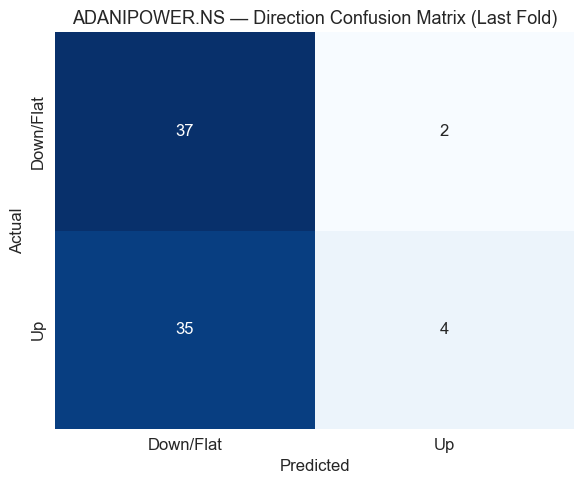

In [15]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down/Flat', 'Up'],
            yticklabels=['Down/Flat', 'Up'], ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('ADANIPOWER.NS — Direction Confusion Matrix (Last Fold)', fontsize=13)
plt.tight_layout()
plt.show()

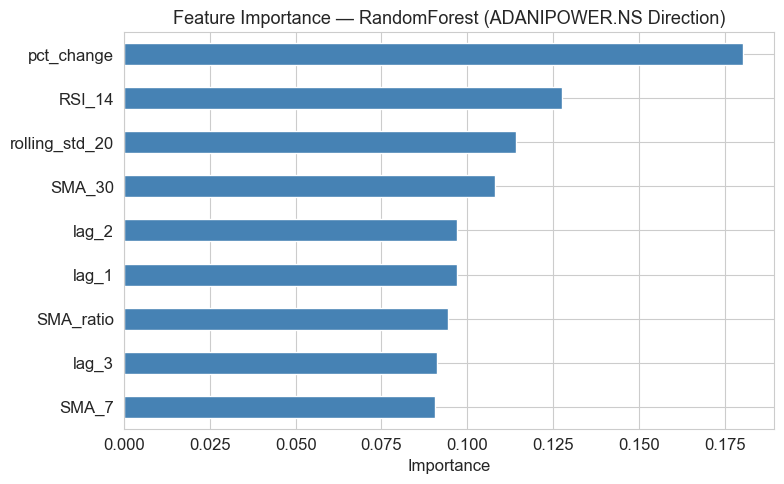

Feature importances:
  pct_change: 0.1803
  RSI_14: 0.1275
  rolling_std_20: 0.1142
  SMA_30: 0.1081
  lag_2: 0.0971
  lag_1: 0.0969
  SMA_ratio: 0.0943
  lag_3: 0.0912
  SMA_7: 0.0905


In [16]:
# Feature importance
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — RandomForest (ADANIPOWER.NS Direction)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Feature importances:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.4f}")

**Result:**  
Mean accuracy is ~55.9% vs a majority-class baseline of ~56.3% - the model actually fails to beat always predicting 'Down.' The confusion matrix confirms a heavy down-bias: 37/39 down days caught but only 4/39 up days (Up recall just 10%). The top feature is `pct_change` (0.18), followed by `RSI_14` (0.13) and `rolling_std_20` (0.11). This is a hard problem: daily direction prediction with price-only features is near random.

---
## 7. Summary

| Section | Key Takeaway |
|---|---|
| Data | 499 trading days per equity, 498 for GOLDBEES; zero nulls after download |
| Normalized Returns | GOLDBEES (+90%) was the top performer; ADANIPOWER (+58%) second; TCS (-44%), WIPRO (-26%), RELIANCE (-12%) all lost value |
| Volatility | ADANIPOWER daily std ~2.77% (most volatile); RELIANCE ~1.30% (least volatile) |
| Correlation | GOLDBEES-equity avg correlation = 0.037 (near zero, TCS slightly negative); strong diversifier |
| Regression (TCS) | Mean R² = 0.878, Mean RMSE = ₹54.98 : high R² inflated by autocorrelation |
| Classification (ADANIPOWER) | Mean accuracy = 55.9% vs 56.3% baseline : does not beat majority-class, heavy down-bias |

